# Firm behavior through time

This notebook reads the complete quarterly `Model` snapshots directly. Its primary view is a firm-by-quarter heatmap: persistent firm IDs form the rows, quarters form the columns, and color represents one selected behavior.

The synchronized aggregate plot helps relate coordinated firm-level changes to emergent model outcomes. These are descriptions of BeforeIT simulations, not empirical causal claims about real economies.

In [1]:
ENV["GKSwstype"] = "100"

using CSV
using DataFrames
using Markdown
using Plots
using Statistics
using TOML

default(; linewidth = 2, framestyle = :box, legend = :best)

trace_root = let
    candidates = unique(normpath.([
        @__DIR__,
        pwd(),
        joinpath(pwd(), "dba-studies", "machine-learning", "explanation-traces"),
    ]))
    matches = filter(path -> isfile(joinpath(path, "experiment.toml")), candidates)
    isempty(matches) && error("Could not locate explanation-traces/experiment.toml")
    first(matches)
end

include(joinpath(trace_root, "src", "explanation_traces.jl"))
using .ExplanationTraces

specification = TOML.parsefile(joinpath(trace_root, "experiment.toml"))
experiment_id = specification["experiment"]["id"]
experiment_directory = joinpath(trace_root, "experiments", experiment_id)
runs_path = joinpath(experiment_directory, "runs.csv")
isfile(runs_path) || error("Missing experiment. Run run_experiment.jl first: $runs_path")
runs = CSV.read(runs_path, DataFrame)
(; trace_root, experiment_id, experiment_directory)

(trace_root = "/Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/machine-learning/explanation-traces", experiment_id = "credit-constraint-quarterly-states-v1", experiment_directory = "/Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/machine-learning/explanation-traces/experiments/credit-constraint-quarterly-states-v1")

## Select and validate a run

The default is the first successful baseline seed. Change `selected_run_id` to inspect another row from the run inventory.

In [2]:
successful_baselines = sort(runs[(runs.success .== true) .& (runs.role .== "baseline"), :], :seed)
isempty(successful_baselines) && error("No successful baseline run found")
selected_run_id = first(successful_baselines.run_id)
selected_run = only(eachrow(filter(:run_id => ==(selected_run_id), runs)))
run_directory = joinpath(experiment_directory, selected_run.snapshot_directory)
paths = snapshot_paths(run_directory)

expected_quarters = collect(0:Int(selected_run.horizon))
quarters = [load_snapshot(path)["quarter"] for path in paths]
checks = DataFrame(
    check = ["run succeeded", "all quarterly files exist", "quarters are contiguous"],
    passed = [selected_run.success, length(paths) == selected_run.horizon + 1, quarters == expected_quarters],
)
all(checks.passed) || error("Snapshot integrity checks failed")
(; selected_run_id, checks)

(selected_run_id = "baseline-seed-4101", checks = 3×2 DataFrame
 Row │ check                      passed 
     │ String                     Bool   
─────┼───────────────────────────────────
   1 │ run succeeded                true
   2 │ all quarterly files exist    true
   3 │ quarters are contiguous      true)

In [3]:
initial_model = load_snapshot(first(paths))["model"]
firm_count = length(initial_model.firms.ID)
available_firm_fields = [
    field for field in fieldnames(typeof(initial_model.firms))
    if getfield(initial_model.firms, field) isa AbstractVector &&
       length(getfield(initial_model.firms, field)) == firm_count
]
DataFrame(field = string.(available_firm_fields))

Row,field
,String
1,ID
2,G_i
3,alpha_bar_i
4,beta_i
5,kappa_i
6,w_i
7,w_bar_i
8,delta_i
9,tau_Y_i


## Build the firm-by-quarter matrix

`measure` may be any aligned firm vector shown above, or `:credit_gap`. For non-negative measures such as production, `:log_change_from_initial` shows each firm's cumulative change from quarter 0 and removes persistent size differences. Use `:raw` for levels, `:signed_log1p` for signed levels, or `:within_firm_zscore` for standardized deviations.

In [4]:
measure = :Y_i
scale = :log_change_from_initial

firm_data = firm_panel(paths)
firm_state = firm_matrix(firm_data, measure)

function transform_values(values, mode)
    transformed = copy(values)
    if mode == :raw
        return transformed, "raw"
    elseif mode == :log_change_from_initial
        source = copy(transformed)
        transformed .= NaN
        for row in axes(source, 1)
            baseline = source[row, 1]
            isfinite(baseline) || continue
            baseline >= 0 || error("log change requires a non-negative quarter-0 value")
            for column in axes(source, 2)
                value = source[row, column]
                isfinite(value) || continue
                value >= 0 || error("log change requires non-negative values")
                transformed[row, column] = log1p(value) - log1p(baseline)
            end
        end
        return transformed, "log(1 + Yᵢₜ) − log(1 + Yᵢ₀)"
    elseif mode == :signed_log1p
        observed = isfinite.(transformed)
        transformed[observed] .= sign.(transformed[observed]) .* log1p.(abs.(transformed[observed]))
        return transformed, "signed log(1 + |x|)"
    elseif mode == :within_firm_zscore
        for row in axes(transformed, 1)
            observed = filter(isfinite, transformed[row, :])
            center = isempty(observed) ? 0.0 : mean(observed)
            spread = length(observed) > 1 ? std(observed) : 0.0
            for column in axes(transformed, 2)
                isfinite(transformed[row, column]) || continue
                transformed[row, column] = spread > 0 ? (transformed[row, column] - center) / spread : 0.0
            end
        end
        return transformed, "within-firm z-score"
    end
    error("Unknown scale: $mode")
end

heatmap_values, scale_label = transform_values(firm_state.values, scale)
scale == :log_change_from_initial && @assert all(isnan(value) || iszero(value) for value in heatmap_values[:, 1])
(; firms = length(firm_state.firm_ids), quarters = firm_state.quarters, measure, scale_label)

(firms = 624, quarters = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], measure = :Y_i, scale_label = "log(1 + Yᵢₜ) − log(1 + Yᵢ₀)")

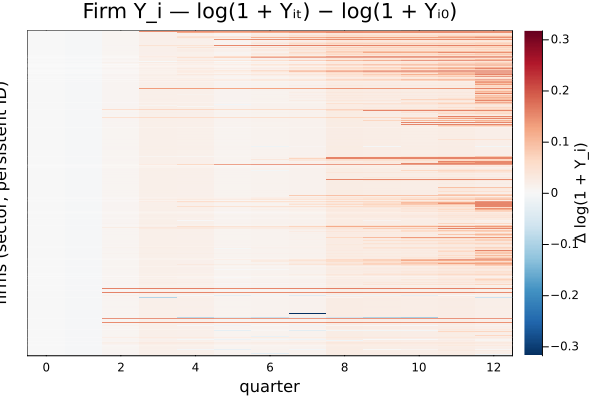

In [5]:
function observed_limits(values; symmetric = false)
    observed = filter(isfinite, vec(values))
    isempty(observed) && error("Heatmap has no finite values")
    if symmetric
        bound = maximum(abs, observed)
        bound = bound == 0 ? 1.0 : bound
        return (-bound, bound)
    end
    low, high = extrema(observed)
    margin = low == high ? max(abs(low) * 0.05, 1.0) : 0.0
    return (low - margin, high + margin)
end

center_on_zero = scale in (:log_change_from_initial, :within_firm_zscore)
heatmap_color_limits = observed_limits(heatmap_values; symmetric = center_on_zero)
heatmap_palette = center_on_zero ? cgrad(:RdBu; rev = true) : cgrad(:viridis)
colorbar_label = scale == :log_change_from_initial ? "Δ log(1 + $(measure))" : string(measure)
center_on_zero && @assert heatmap_color_limits[1] == -heatmap_color_limits[2]

function firm_heatmap(
    state, values; cursor = nothing, color_limits = heatmap_color_limits, palette = heatmap_palette,
)
    chart = heatmap(
        state.quarters, collect(axes(values, 1)), values;
        xlabel = "quarter",
        ylabel = "firms (sector, persistent ID)",
        title = "Firm $(state.measure) — $scale_label",
        color = palette,
        colorbar = true,
        colorbar_title = colorbar_label,
        clims = color_limits,
        background_color_inside = :lightgray,
        yflip = true,
        yticks = false,
        legend = false,
    )
    boundaries = [
        row for row in 1:(length(state.sectors) - 1)
        if state.sectors[row] != state.sectors[row + 1]
    ]
    isempty(boundaries) || hline!(chart, boundaries .+ 0.5; color = :white, alpha = 0.35, linewidth = 0.5, label = false)
    isnothing(cursor) || vline!(chart, [cursor]; color = :red, linewidth = 2, label = false)
    return chart
end

firm_heatmap(firm_state, heatmap_values)

## Connect firm behavior to an emergent outcome

The panels share the quarter axis. This does not establish causality, but it makes the timing of micro-level coordination and aggregate movement directly inspectable.

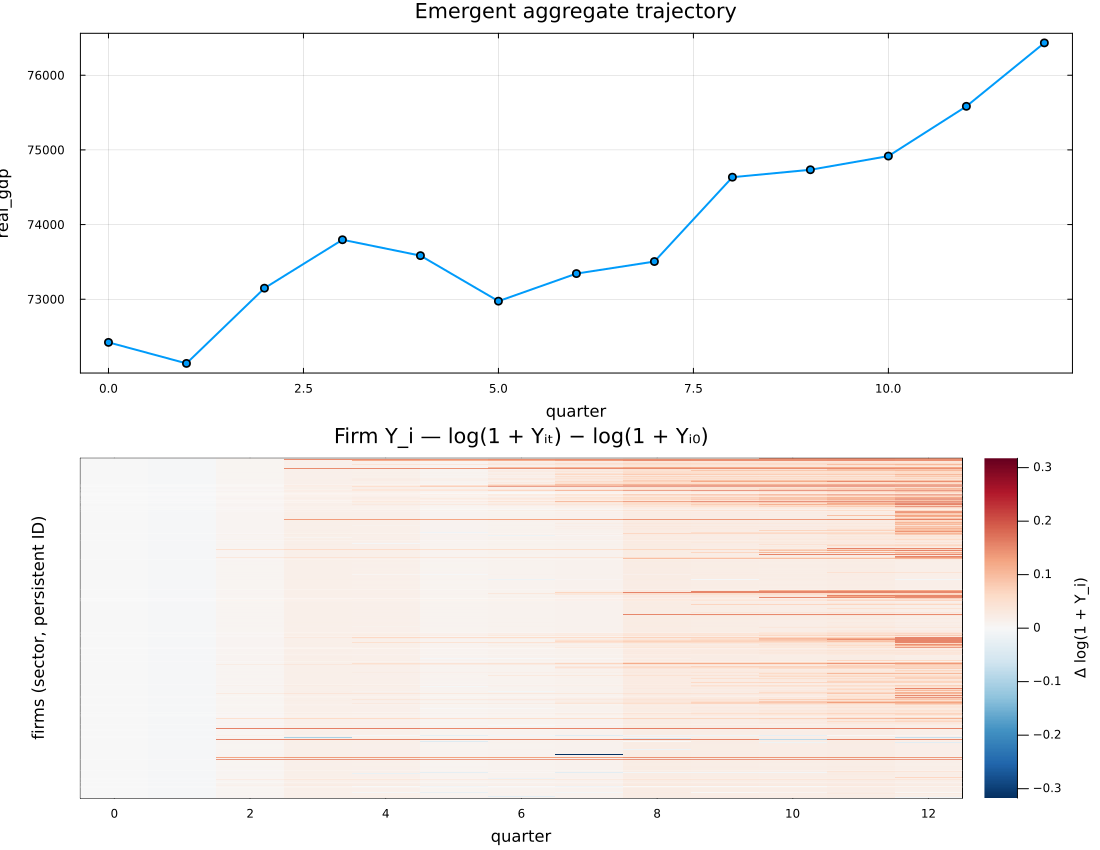

In [6]:
aggregate_field = :real_gdp
aggregate = aggregate_series(paths, aggregate_field)
aggregate_plot = plot(
    aggregate.quarter, aggregate.value;
    marker = :circle,
    xlabel = "quarter",
    ylabel = string(aggregate_field),
    title = "Emergent aggregate trajectory",
    label = false,
)
plot(aggregate_plot, firm_heatmap(firm_state, heatmap_values); layout = (2, 1), size = (1100, 850))

## Bankruptcy and employment decisions

A bankruptcy trigger marks a firm with both negative deposits (`D_i < 0`) and negative equity (`E_i < 0`) at the end of a quarter. The bank refinances that same firm at the start of the next quarter, so this is an insolvency event rather than firm deletion.

The employment decision compares current desired employment with the previous quarter's actual employment: `N_d_i[t] - N_i[t-1]`. The heatmap shows direction only: firing, unchanged, or hiring; quarter 0 is unavailable because it has no prior snapshot.

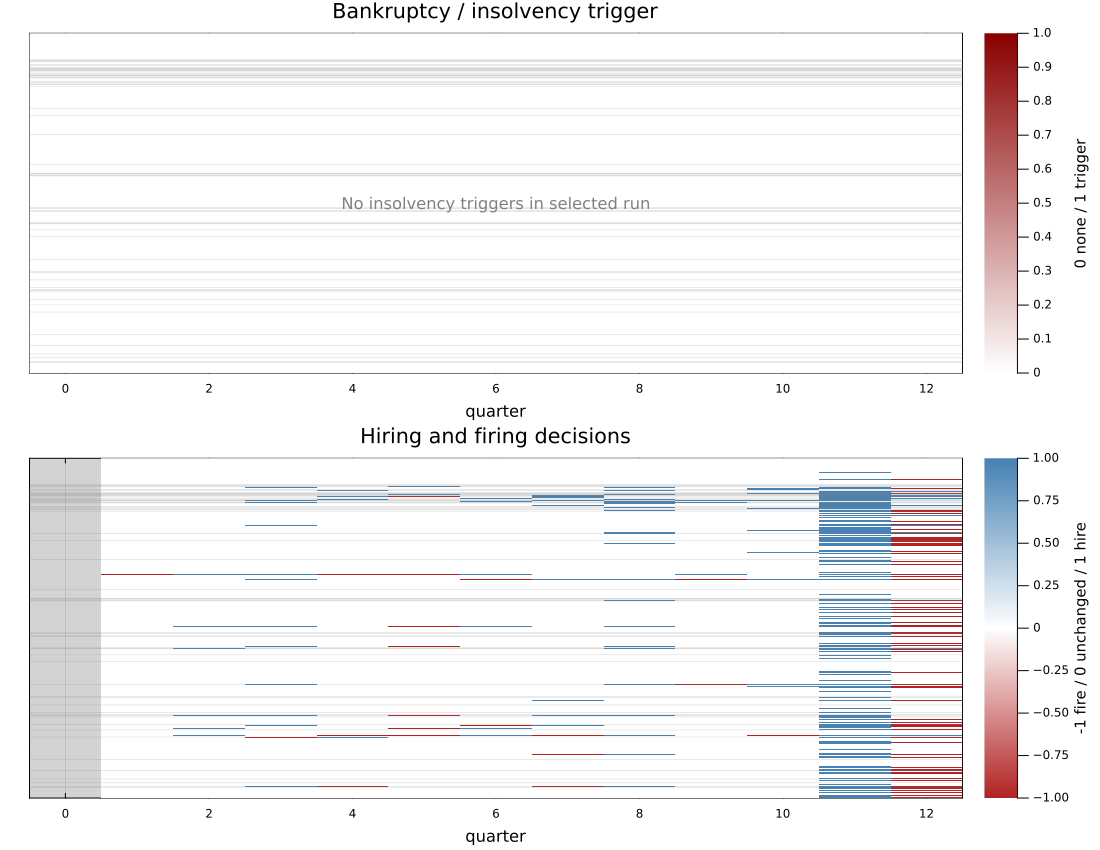

In [7]:
transition_data = firm_transition_panel(paths)
bankruptcy_state = firm_matrix(transition_data, :bankruptcy_trigger)
employment_state = firm_matrix(transition_data, :employment_decision_direction)

function transition_heatmap(
    state; title, palette, color_limits, colorbar_title, empty_message = nothing,
)
    chart = heatmap(
        state.quarters, collect(axes(state.values, 1)), state.values;
        xlabel = "quarter",
        ylabel = "firms (sector, persistent ID)",
        title,
        color = palette,
        colorbar = true,
        colorbar_title,
        clims = color_limits,
        background_color_inside = :lightgray,
        yflip = true,
        yticks = false,
        legend = false,
    )
    boundaries = [
        row for row in 1:(length(state.sectors) - 1)
        if state.sectors[row] != state.sectors[row + 1]
    ]
    isempty(boundaries) || hline!(
        chart, boundaries .+ 0.5;
        color = :gray, alpha = 0.35, linewidth = 0.5, label = false,
    )
    if !isnothing(empty_message) && !any(value -> isfinite(value) && value == 1, state.values)
        annotate!(
            chart,
            (first(state.quarters) + last(state.quarters)) / 2,
            (first(axes(state.values, 1)) + last(axes(state.values, 1))) / 2,
            text(empty_message, 11, :gray),
        )
    end
    return chart
end

bankruptcy_plot = transition_heatmap(
    bankruptcy_state;
    title = "Bankruptcy / insolvency trigger",
    palette = cgrad([:white, :darkred]),
    color_limits = (0, 1),
    colorbar_title = "0 none / 1 trigger",
    empty_message = "No insolvency triggers in selected run",
)
employment_plot = transition_heatmap(
    employment_state;
    title = "Hiring and firing decisions",
    palette = cgrad([:firebrick, :white, :steelblue]),
    color_limits = (-1, 1),
    colorbar_title = "-1 fire / 0 unchanged / 1 hire",
)
plot(bankruptcy_plot, employment_plot; layout = (2, 1), size = (1100, 850))

## Time-flowing view

The animation progressively reveals the same matrix. Future quarters remain blank, while a shared red marker moves through the aggregate trajectory and firm heatmap.

[ Info: Saved animation to /Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/machine-learning/explanation-traces/experiments/credit-constraint-quarterly-states-v1/derived/baseline-seed-4101-Y_i-heatmap.gif


Plots.AnimatedGif("/Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/machine-learning/explanation-traces/experiments/credit-constraint-quarterly-states-v1/derived/baseline-seed-4101-Y_i-heatmap.gif")
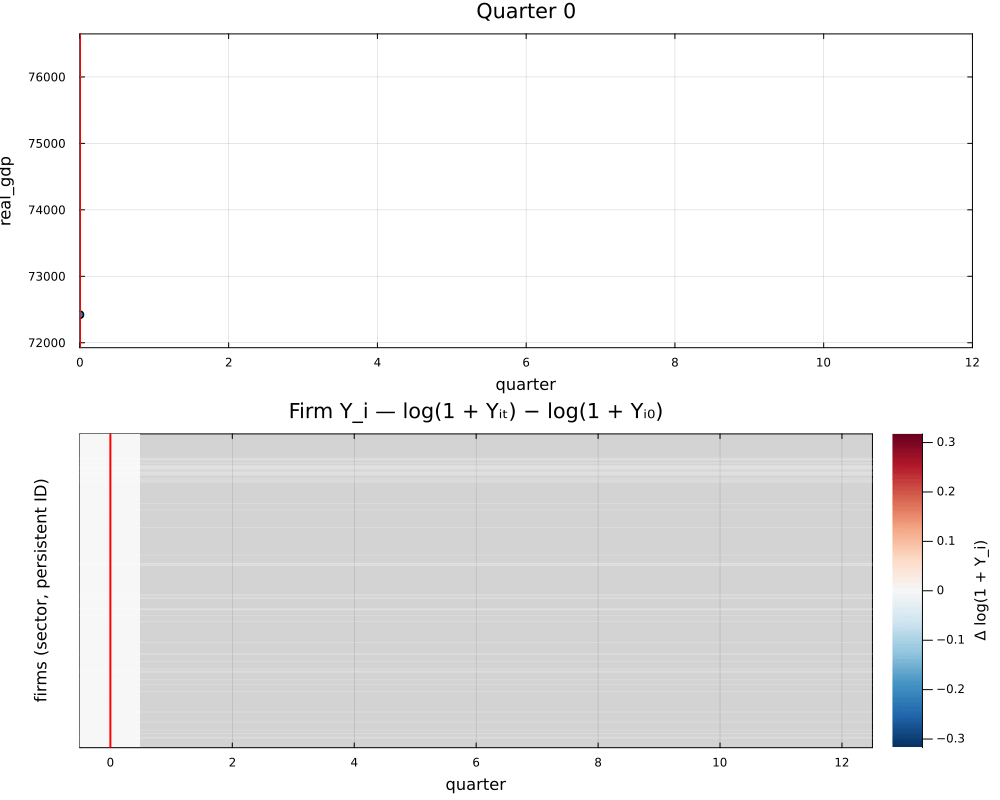

In [8]:
function flowing_heatmap(
    state, values, aggregate; fps = 2, output_path = tempname() * ".gif",
    color_limits = heatmap_color_limits, palette = heatmap_palette,
)
    aggregate_low, aggregate_high = extrema(aggregate.value)
    aggregate_margin = max((aggregate_high - aggregate_low) * 0.05, 1.0)
    aggregate_limits = (aggregate_low - aggregate_margin, aggregate_high + aggregate_margin)
    animation = @animate for column in eachindex(state.quarters)
        visible = fill(NaN, size(values))
        visible[:, 1:column] .= values[:, 1:column]
        quarter = state.quarters[column]
        top = plot(
            aggregate.quarter[1:column], aggregate.value[1:column];
            marker = :circle, xlabel = "quarter", ylabel = string(aggregate_field),
            title = "Quarter $quarter", label = false,
            xlims = extrema(aggregate.quarter), ylims = aggregate_limits,
        )
        vline!(top, [quarter]; color = :red, linewidth = 2, label = false)
        bottom = firm_heatmap(state, visible; cursor = quarter, color_limits, palette)
        plot(top, bottom; layout = (2, 1), size = (1000, 800))
    end
    return gif(animation, output_path; fps)
end

animation_directory = joinpath(experiment_directory, "derived")
mkpath(animation_directory)
animation_path = joinpath(animation_directory, "$(selected_run_id)-$(measure)-heatmap.gif")
flowing_heatmap(firm_state, heatmap_values, aggregate; output_path = animation_path)

## Input-output network and sector hubs

`a_sg[g, s]` is the share of input product `g` in buyer sector `s`, so it defines a weighted directed network from supplier sector `g` to buyer sector `s`. Every firm inherits the structural neighborhood of its sector. This is a **potential supply network**: the model randomly matches individual buyers and sellers within each quarter, and those realized counterparties are not retained in the quarterly snapshots.

The ranking uses weighted HITS hub centrality on the complete matrix. Reach counts retain links representing at least 1% of a buyer sector's input mix. The graph keeps every sector but draws only each buyer's strongest non-self supplier link to avoid an unreadable hairball; pruning affects the picture, not the hub scores.

(sectors = 62, firms = 624, reach_threshold = 0.01, retained_input_weight = 0.916)

Row,sector,firms,customer_sectors,potential_customer_firms,supplier_sectors,potential_supplier_firms,weighted_out_strength,hub_score
,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64
1,45,42,53,564,13,184,3.422,0.0651
2,44,12,49,556,10,123,3.328,0.0637
3,27,41,48,503,17,176,2.692,0.0503
4,29,35,50,509,24,309,2.949,0.0459
5,41,2,59,620,14,254,2.487,0.0451
6,24,3,36,376,6,13,2.28,0.0433
7,11,1,23,189,10,109,2.251,0.0391
8,50,4,40,577,17,248,1.815,0.032
9,34,2,16,136,17,228,1.799,0.0297


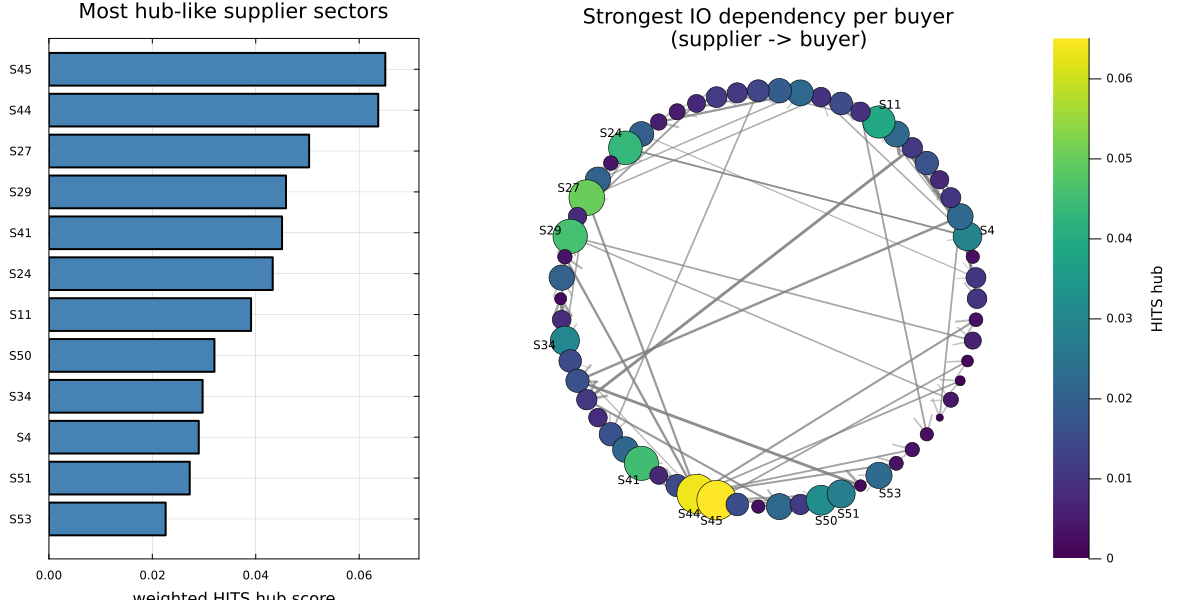

In [9]:
io_weights = Float64.(initial_model.prop.a_sg)
sector_count = size(io_weights, 1)
@assert size(io_weights) == (sector_count, sector_count)
@assert all(io_weights .>= 0)
@assert all(isapprox.(vec(sum(io_weights; dims = 1)), 1.0; atol = 1.0e-10))

function hits_scores(weights; tolerance = 1.0e-12, max_iterations = 1_000)
    hubs = fill(1.0 / size(weights, 1), size(weights, 1))
    for _ in 1:max_iterations
        authorities = transpose(weights) * hubs
        authorities ./= sum(authorities)
        next_hubs = weights * authorities
        next_hubs ./= sum(next_hubs)
        converged = maximum(abs.(next_hubs .- hubs)) < tolerance
        hubs = next_hubs
        converged && break
    end
    authorities = transpose(weights) * hubs
    authorities ./= sum(authorities)
    return hubs, authorities
end

edge_threshold = 0.01
io_support = io_weights .>= edge_threshold
sector_firm_counts = [count(==(sector), initial_model.firms.G_i) for sector in 1:sector_count]
hub_score, authority_score = hits_scores(io_weights)
@assert isapprox(sum(hub_score), 1.0; atol = 1.0e-10)

potential_customer_firms = [
    sum(sector_firm_counts[io_support[sector, :]]) for sector in 1:sector_count
]
potential_supplier_firms = [
    sum(sector_firm_counts[io_support[:, sector]]) for sector in 1:sector_count
]
sector_connectivity = DataFrame(
    sector = 1:sector_count,
    firms = sector_firm_counts,
    customer_sectors = vec(sum(io_support; dims = 2)),
    potential_customer_firms = potential_customer_firms,
    supplier_sectors = vec(sum(io_support; dims = 1)),
    potential_supplier_firms = potential_supplier_firms,
    weighted_out_strength = vec(sum(io_weights; dims = 2)),
    hub_score = hub_score,
    authority_score = authority_score,
)
firm_connectivity = DataFrame(
    firm_id = initial_model.firms.ID,
    sector = initial_model.firms.G_i,
    potential_customer_firms = potential_customer_firms[initial_model.firms.G_i],
    potential_supplier_firms = potential_supplier_firms[initial_model.firms.G_i],
    sector_hub_score = hub_score[initial_model.firms.G_i],
)
@assert nrow(firm_connectivity) == length(initial_model.firms.ID)

hub_ranking = sort(sector_connectivity, :hub_score; rev = true)
top_count = min(12, sector_count)
top_hubs = first(hub_ranking, top_count)
display((
    sectors = sector_count,
    firms = nrow(firm_connectivity),
    reach_threshold = edge_threshold,
    retained_input_weight = round(sum(io_weights[io_support]) / sum(io_weights); digits = 3),
))
hub_display = select(
    top_hubs, :sector, :firms, :customer_sectors, :potential_customer_firms,
    :supplier_sectors, :potential_supplier_firms, :weighted_out_strength, :hub_score,
)
hub_display.weighted_out_strength = round.(hub_display.weighted_out_strength; digits = 3)
hub_display.hub_score = round.(hub_display.hub_score; digits = 4)
display(hub_display)

hub_bar = bar(
    reverse(top_hubs.hub_score);
    orientation = :h,
    yticks = (1:top_count, reverse(["S$sector" for sector in top_hubs.sector])),
    xlabel = "weighted HITS hub score",
    title = "Most hub-like supplier sectors",
    xlims = (0, 1.1 * maximum(top_hubs.hub_score)),
    color = :steelblue,
    label = false,
)

angles = range(0, 2pi; length = sector_count + 1)[1:end-1]
x_position, y_position = cos.(angles), sin.(angles)
strongest_edges = map(1:sector_count) do buyer
    weights = copy(io_weights[:, buyer])
    weights[buyer] = -Inf
    supplier = argmax(weights)
    (; supplier, buyer, weight = io_weights[supplier, buyer])
end
max_edge_weight = maximum(edge -> edge.weight, strongest_edges)
network_plot = plot(
    ; aspect_ratio = :equal, xlims = (-1.25, 1.25), ylims = (-1.25, 1.25),
    axis = false, grid = false, framestyle = :none,
    title = "Strongest IO dependency per buyer
(supplier -> buyer)",
)
for edge in strongest_edges
    relative_weight = sqrt(edge.weight / max_edge_weight)
    plot!(
        network_plot,
        [x_position[edge.supplier], x_position[edge.buyer]],
        [y_position[edge.supplier], y_position[edge.buyer]];
        color = :gray, alpha = 0.2 + 0.6 * relative_weight,
        linewidth = 0.4 + 3 * relative_weight, arrow = true, label = false,
    )
end
relative_hub = hub_score ./ maximum(hub_score)
scatter!(
    network_plot, x_position, y_position;
    marker_z = hub_score, color = :viridis, colorbar = true, colorbar_title = "HITS hub",
    markersize = 4 .+ 18 .* sqrt.(relative_hub), markerstrokewidth = 0.5, label = false,
)
for sector in top_hubs.sector
    annotate!(
        network_plot, 1.1 * x_position[sector], 1.1 * y_position[sector],
        text("S$sector", 8, :black),
    )
end

plot(hub_bar, network_plot; layout = grid(1, 2; widths = [0.35, 0.65]), size = (1200, 600))

## Network-linked output and employment heatmaps

The left panel of each chart shows the behavior of each supplier sector through time. The right panel maps that behavior into each buyer sector through the input-output matrix: $x^{network}_{s,t} = \sum_g a_{g,s}x_{g,t}$. Because each column of `a_sg` sums to one, the network panel is the input-share-weighted behavior of a buyer's suppliers.

Output is the percentage change in total sector output from quarter 0. Hiring and firing is the sector's net desired employment change as a percentage of its previous-quarter employment; negative values mean net firing and positive values mean net hiring. These are structural exposure maps, not realized firm-to-firm transaction maps.

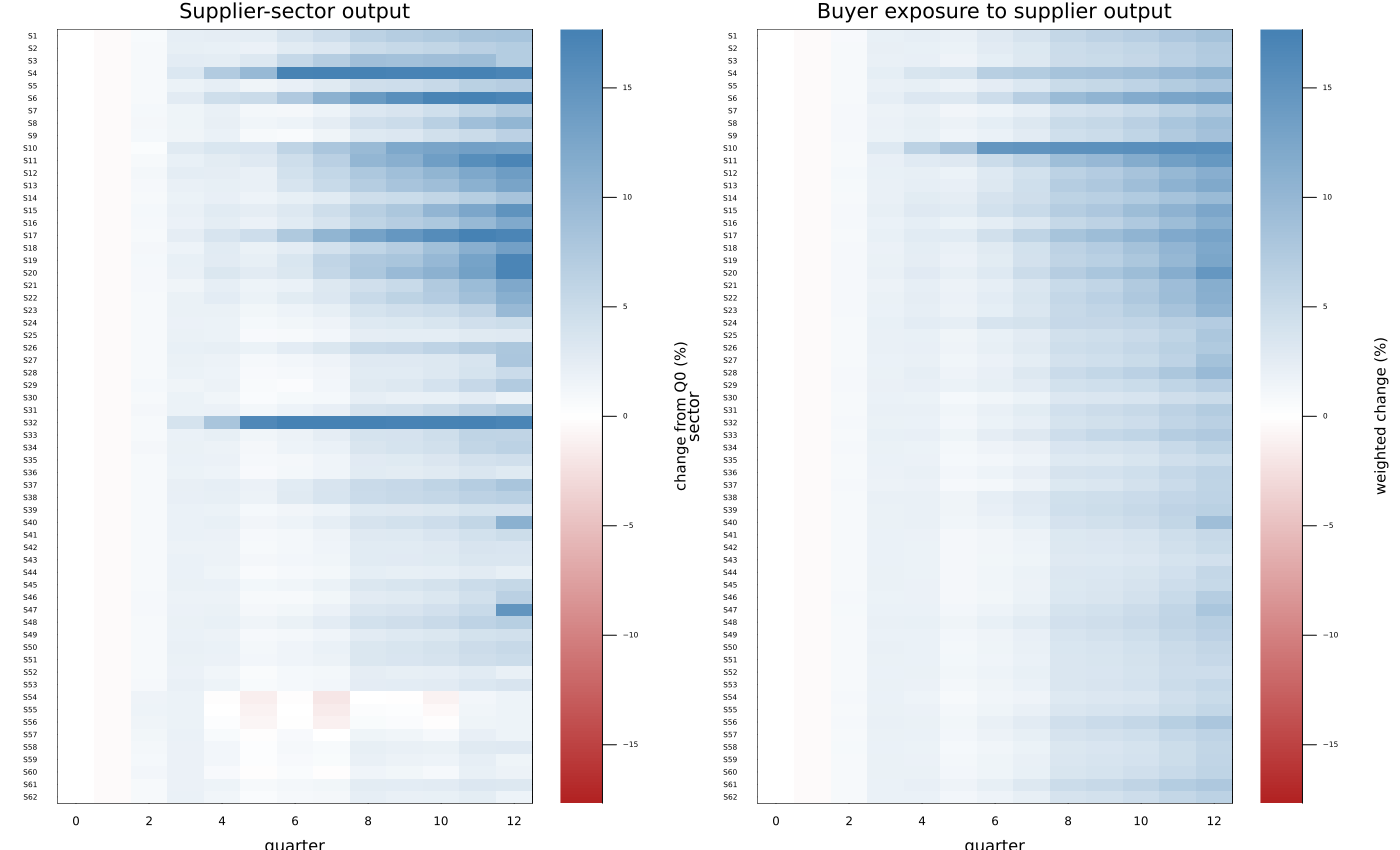

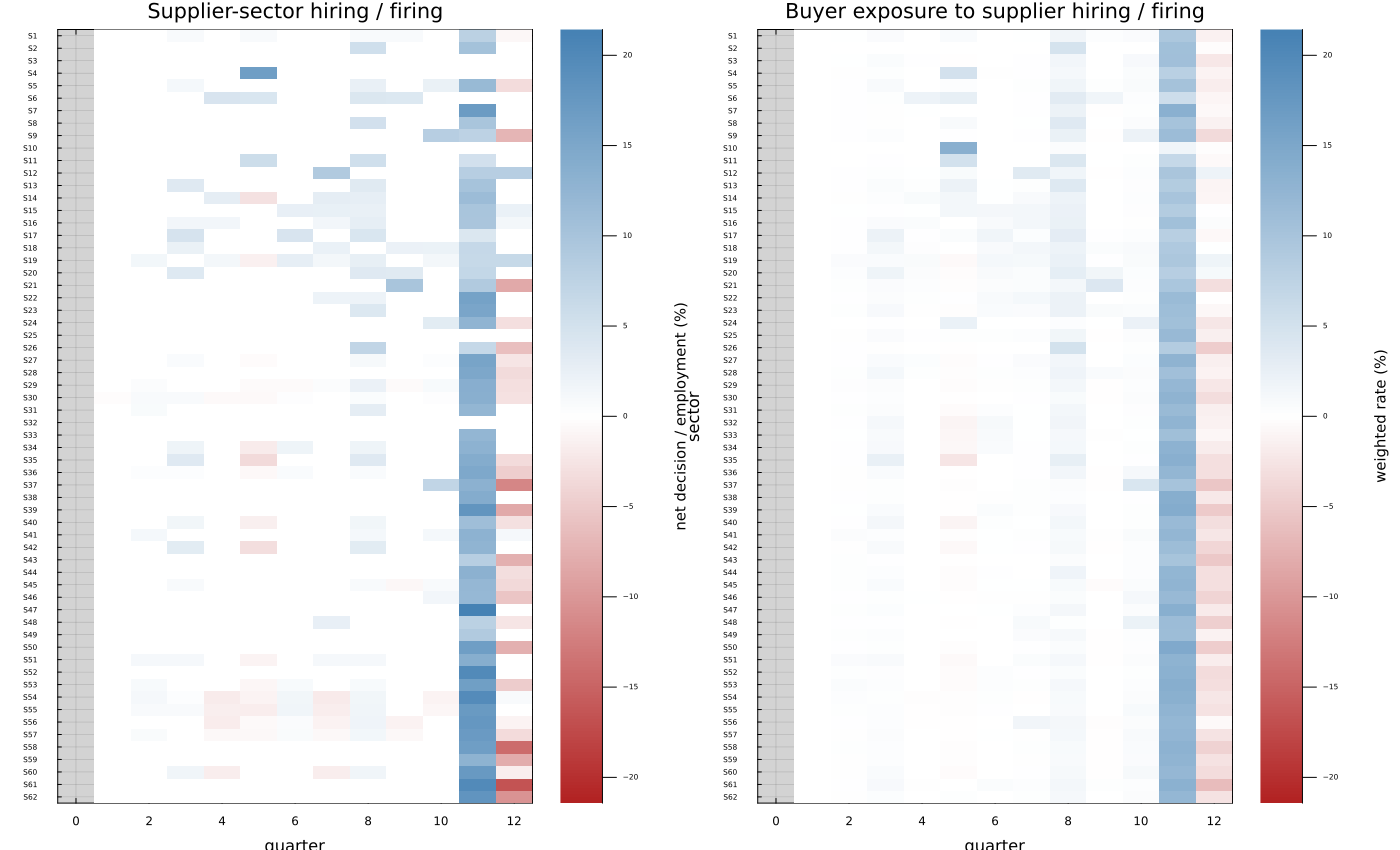

In [10]:
function sector_matrix(panel, measure, sector_count, quarters)
    values = zeros(sector_count, length(quarters))
    quarter_index = Dict(quarter => index for (index, quarter) in enumerate(quarters))
    for row in eachrow(panel)
        sector = Int(row.sector)
        1 <= sector <= sector_count || error("Sector $sector is outside 1:$sector_count")
        value = row[measure]
        ismissing(value) || (values[sector, quarter_index[Int(row.quarter)]] += Float64(value))
    end
    return values
end

sector_output = sector_matrix(firm_data, :Y_i, sector_count, quarters)
sector_employment = sector_matrix(firm_data, :N_i, sector_count, quarters)
sector_decisions = sector_matrix(transition_data, :employment_decision, sector_count, quarters)
@assert all(sector_output[:, 1] .> 0)
@assert isapprox(
    sum(sector_output[:, end]),
    sum(firm_data[firm_data.quarter .== last(quarters), :Y_i]); atol = 1.0e-10,
)

sector_output_change = 100 .* (sector_output ./ sector_output[:, 1:1] .- 1)
sector_hiring_rate = fill(NaN, sector_count, length(quarters))
for column in 2:length(quarters)
    sector_hiring_rate[:, column] .=
        100 .* sector_decisions[:, column] ./ max.(sector_employment[:, column - 1], 1)
end
network_output_change = transpose(io_weights) * sector_output_change
network_hiring_rate = transpose(io_weights) * sector_hiring_rate
@assert all(iszero, network_output_change[:, 1])
@assert all(isnan, network_hiring_rate[:, 1])

function sector_heatmap(values; title, color_limits, colorbar_title)
    heatmap(
        quarters, 1:sector_count, values;
        xlabel = "quarter", ylabel = "sector", title,
        yticks = (1:sector_count, ["S$sector" for sector in 1:sector_count]),
        ytickfontsize = 5, yflip = true,
        color = cgrad([:firebrick, :white, :steelblue]),
        colorbar = true, colorbar_title, clims = color_limits,
        background_color_inside = :lightgray, legend = false,
    )
end

output_limits = observed_limits(
    vcat(sector_output_change, network_output_change); symmetric = true,
)
hiring_limits = observed_limits(
    vcat(sector_hiring_rate, network_hiring_rate); symmetric = true,
)
output_charts = plot(
    sector_heatmap(
        sector_output_change; title = "Supplier-sector output",
        color_limits = output_limits, colorbar_title = "change from Q0 (%)",
    ),
    sector_heatmap(
        network_output_change; title = "Buyer exposure to supplier output",
        color_limits = output_limits, colorbar_title = "weighted change (%)",
    ); layout = (1, 2), size = (1400, 850),
)
employment_charts = plot(
    sector_heatmap(
        sector_hiring_rate; title = "Supplier-sector hiring / firing",
        color_limits = hiring_limits, colorbar_title = "net decision / employment (%)",
    ),
    sector_heatmap(
        network_hiring_rate; title = "Buyer exposure to supplier hiring / firing",
        color_limits = hiring_limits, colorbar_title = "weighted rate (%)",
    ); layout = (1, 2), size = (1400, 850),
)
display(output_charts)
display(employment_charts)

## Reuse the same pipeline

Change `measure` and, when appropriate, `scale`, then rerun from **Build the firm-by-quarter matrix**. Useful first comparisons are `:N_i` for employment, `:Pi_i` for profit, `:E_i` for distress, and `:credit_gap` for rationing. `:log_change_from_initial` requires non-negative values; use `:signed_log1p` or `:within_firm_zscore` for signed measures. Use one measure per heatmap so color retains a clear meaning.

In [11]:
DataFrame(
    run_id = runs.run_id,
    scenario = runs.scenario_id,
    seed = runs.seed,
    quarters = runs.snapshots_written,
    storage_mib = round.(runs.total_bytes ./ 1024^2; digits = 2),
    runtime_seconds = round.(runs.runtime_seconds; digits = 2),
    success = runs.success,
)

Row,run_id,scenario,seed,quarters,storage_mib,runtime_seconds,success
,String,String,Int64,Int64,Float64,Float64,Bool
1,baseline-seed-4101,baseline,4101,13,11.99,3.82,true
2,tighter-firm-loan-to-value-limit-seed-4101,tighter-firm-loan-to-value-limit,4101,13,12.0,0.61,true
3,baseline-seed-4102,baseline,4102,13,11.99,0.42,true
4,tighter-firm-loan-to-value-limit-seed-4102,tighter-firm-loan-to-value-limit,4102,13,12.0,0.49,true
5,baseline-seed-4103,baseline,4103,13,11.99,0.4,true
6,tighter-firm-loan-to-value-limit-seed-4103,tighter-firm-loan-to-value-limit,4103,13,12.0,0.5,true
